### Phase 2: Feature Engineering (Der "Signal-Geber")
Modelle benötigen Input, um Regimes zu erkennen. Wir wandeln Rohdaten in stationäre Features um.

Features erfolgreich erstellt. Spalten im DataFrame: ['Returns_GSPC', 'Returns_VUSTX', 'Returns', 'Cumulative_Returns', 'Cash_Returns', 'VIX', 'TNX_10Y', 'IRX_3M', 'Vol_20', 'SMA_200', 'Distance_SMA', 'Momentum', 'Yield_Spread']


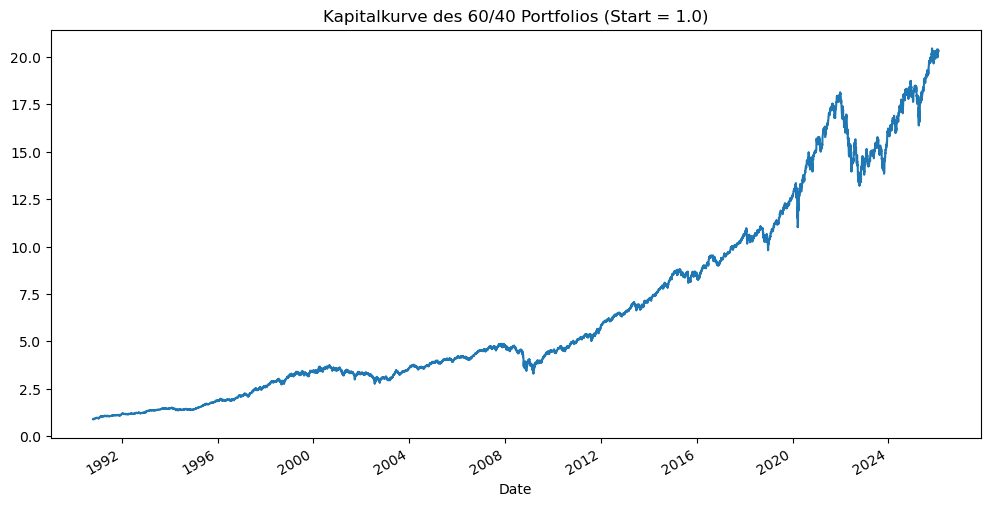

            Returns_GSPC  Returns_VUSTX   Returns  Cumulative_Returns  \
Date                                                                    
1990-10-18      0.023363       0.006586  0.016652            0.902545   
1990-10-19      0.022045       0.008726  0.016717            0.917634   
1990-10-22      0.007296      -0.001082  0.003945            0.921254   
1990-10-23     -0.007625      -0.002166 -0.005441            0.916241   
1990-10-24      0.000768      -0.001084  0.000027            0.916266   
...                  ...            ...       ...                 ...   
2026-01-27      0.004082      -0.004981  0.000457           20.386146   
2026-01-28     -0.000082      -0.002503 -0.001050           20.364735   
2026-01-29     -0.001293       0.000000 -0.000776           20.348941   
2026-01-30     -0.004302      -0.003764 -0.004087           20.265779   
2026-02-02      0.005391      -0.003778  0.001723           20.300706   

            Cash_Returns        VIX  TNX_10Y  IRX_

In [1]:
# --- Phase 2: Feature Engineering ---

import matplotlib.pyplot as plt
import pandas as pd

# Daten aus dem data-Ordner laden
df = pd.read_parquet("../data/01_preprocessed_data.parquet")

# Wir nutzen 'Cumulative_Returns' als unseren "Preis", da dies den Wert des 60/40 Portfolios über die Zeit darstellt

df['Vol_20'] = df['Returns'].rolling(20).std()
df['SMA_200'] = df['Cumulative_Returns'].rolling(200).mean()
df['Distance_SMA'] = (df['Cumulative_Returns'] - df['SMA_200']) / df['SMA_200']
df['Momentum'] = df['Returns'].rolling(10).mean()
# Renditestrukturkurve (10Y - 3M Spread) - Ein inverser Spread (3M > 10Y) ist ein klassischer Rezessionsindikator
df['Yield_Spread'] = df['TNX_10Y'] - df['IRX_3M']

# Zeilen mit NaN-Werten (durch rolling) entfernen
df = df.dropna()

# Kurze Kontrolle
print("Features erfolgreich erstellt. Spalten im DataFrame:", df.columns.tolist())

# Visualisierung der Kapitalkurve des Portfolios
df['Cumulative_Returns'].plot(figsize=(12,6), title="Kapitalkurve des 60/40 Portfolios (Start = 1.0)")
# Capital Curve persistieren
plt.savefig('../assets/capital_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(df)

In [2]:
output_path = "../data/02_feature_engineered_data.parquet"

# Speichern als Parquet
df.to_parquet(output_path)

print(f"Dataframe erfolgreich unter {output_path} gespeichert.")

Dataframe erfolgreich unter ../data/02_feature_engineered_data.parquet gespeichert.
